In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('1_boston_housing.csv')

In [3]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [4]:
df.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

In [5]:
x = df.drop('MEDV',axis=1)
y = df['MEDV']


In [6]:
from sklearn.model_selection import train_test_split

In [7]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [8]:
from keras.models import Sequential
from keras.layers import Dense

In [9]:
from sklearn.preprocessing import StandardScaler

In [10]:
sc = StandardScaler()

In [11]:
x_train = sc.fit_transform(x_train)


In [12]:
from keras.layers import Dropout

In [13]:
from keras.layers import Activation

In [14]:
model = Sequential()

In [15]:
model.add(Dense(128,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(16,activation='relu'))
model.add(Dense(1,activation='linear'))

In [16]:
model.compile(optimizer='adam',loss='mse',metrics=['mae'])

In [17]:
history = model.fit(x_train,y_train,epochs=45,validation_split=0.05,verbose=1)

Epoch 1/45
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 604.3624 - mae: 22.7212 - val_loss: 514.9448 - val_mae: 21.2128
Epoch 2/45
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 575.0934 - mae: 22.0803 - val_loss: 474.2959 - val_mae: 20.2696
Epoch 3/45
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 504.6460 - mae: 20.4226 - val_loss: 372.7313 - val_mae: 17.6926
Epoch 4/45
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 332.8082 - mae: 15.9230 - val_loss: 162.7452 - val_mae: 10.5746
Epoch 5/45
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 108.7871 - mae: 8.4663 - val_loss: 59.2292 - val_mae: 4.8651
Epoch 6/45
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 57.5200 - mae: 5.9063 - val_loss: 56.1048 - val_mae: 4.3958
Epoch 7/45
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 33.4958 - mae: 4.2805 - val_loss: 59.0500 - val_mae: 4.5747
Epoch 8/45
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 25.8854 - mae: 3.6938 - val_loss: 56.0853 - val_mae: 4.6767
Epoch 9/45
12/12 ━━━━━━━━━━━━━━━━━━━━ 

In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,021 (148.52 KB)

 Trainable params: 12,673 (49.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 25,348 (99.02 KB)

In [19]:
loss,mae = model.evaluate(x_test,y_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7726432.5000 - mae: 2738.9700 


In [20]:
y_pred = model.predict(x_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


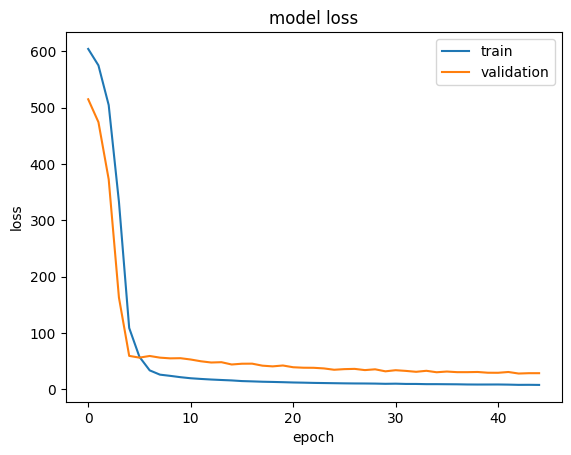

In [21]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','validation'],loc='upper right')
plt.show()